# !DataSet:
https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset

In [43]:
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [44]:
# Load the data
data_path = Path('./dataset/loan_approval_dataset.csv')

print("data_path.exists(): ",data_path.exists())  # Check if the file exists
#print(data_path.is_file())  # Check if the file exists
#print(data_path.is_dir() )  # Check if the file exists
#print(data_path)  # Print the path to the file
df = pd.read_csv(data_path)
print(df.head())  # Display the first few rows of the DataFrame


data_path.exists():  True
   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \


In [45]:
df.shape

(4269, 13)

In [46]:
df.columns.tolist()

['loan_id',
 ' no_of_dependents',
 ' education',
 ' self_employed',
 ' income_annum',
 ' loan_amount',
 ' loan_term',
 ' cibil_score',
 ' residential_assets_value',
 ' commercial_assets_value',
 ' luxury_assets_value',
 ' bank_asset_value',
 ' loan_status']

In [47]:
# Fix space issue in column names
df.columns = df.columns.str.strip()

In [48]:
df.columns.to_list()

['loan_id',
 'no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

In [49]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [50]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


# EDA

In [51]:
target_col = 'loan_status'

Using target_col:  loan_status


loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

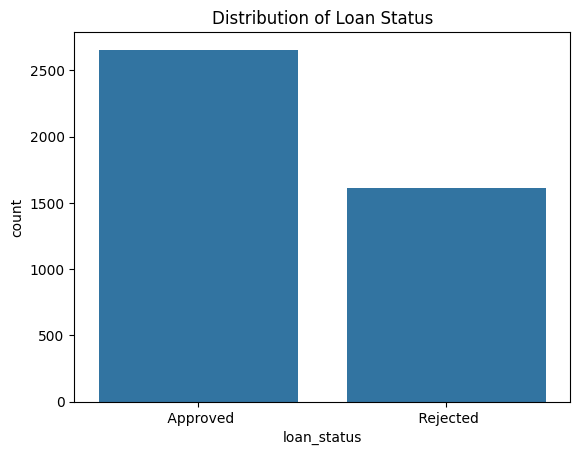

In [52]:
print("Using target_col: ", target_col)
display(df[target_col].value_counts(dropna=False))
sns.countplot(x=target_col, data=df)
plt.title('Distribution of Loan Status')
plt.show()

In [53]:
df = df.drop(columns=['loan_id'], errors='ignore')

In [54]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [55]:
df.info()  # Get information about the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [56]:
# drop records with target_col null
df_clf = df.dropna(subset=[target_col]).copy()



In [58]:
# X and y for modeling
X = df_clf.drop(columns=[target_col])
y = df_clf[target_col].copy()

In [59]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [60]:
y.head()

0     Approved
1     Rejected
2     Rejected
3     Rejected
4     Rejected
Name: loan_status, dtype: object

# Feature Types

In [61]:
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
print("Categorical columns: ", cat_cols)
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical columns: ", num_cols)

Categorical columns:  ['education', 'self_employed']
Numerical columns:  ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


# Preprocessing Pipeline

In [62]:
from sklearn.impute import SimpleImputer
#Onehot encoding for categorical columns and Standard scaling for numerical columns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
#helps to transform categorical and numerical columns in a single step
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [63]:
numerical_transformer = Pipeline( steps=[
  ('imputer',SimpleImputer(strategy='median')),
  ('scaler',StandardScaler())
])

#Scaler is used to normalize the scale issue. Example Salary and number of exp
    


In [64]:

categorical_transformer = Pipeline ( steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore')) 
])

# onehot Encoder - use Red,Blue,Yellow as 0 0 1 like that

In [65]:
preprocessor = ColumnTransformer(transformers=[
    ('num',numerical_transformer,num_cols),
    ('cat',categorical_transformer,cat_cols)
],remainder='drop')
    


In [66]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


# Stage - 1 Classification baseline

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [68]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [69]:
y.head()

0     Approved
1     Rejected
2     Rejected
3     Rejected
4     Rejected
Name: loan_status, dtype: object

In [70]:
unique_vals = sorted(y.unique())
unique_vals

[' Approved', ' Rejected']

In [71]:
y = df_clf[target_col].astype(str).str.strip().str.lower()

In [72]:
unique_vals = sorted(y.unique())
unique_vals

['approved', 'rejected']

In [73]:
y = (y=='approved').astype(int)

In [74]:
unique_vals = sorted(y.unique())
unique_vals

[np.int64(0), np.int64(1)]

In [75]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: loan_status, dtype: int64

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=10,stratify=y)

print("Train Size :", X_train.shape)
print("Test Size :", X_test.shape)

Train Size : (3415, 11)
Test Size : (854, 11)


# Fit Random Forest baseline pipelines

In [77]:
rf_clf_pipeline = Pipeline( steps=[
 ('preprocessor',preprocessor),
 ('rf_cls',RandomForestClassifier())
])

In [78]:
from sklearn.model_selection import GridSearchCV

In [79]:
from math import sqrt



param_grid = {
    'rf_cls__n_estimators':[100,200,300,400],
    'rf_cls__max_depth':[None,4,8,10],
    'rf_cls__max_features':['sqrt',None]
}

grid = GridSearchCV(rf_clf_pipeline,param_grid,cv=5,scoring='f1',n_jobs=-1)
grid.fit(X_train,y_train)
print("Best params (rf_cls) :", grid.best_params_)
best_clf = grid.best_estimator_
y_pred_best = best_clf.predict(X_test)
print(classification_report(y_test,y_pred_best))

# n_estimators: How many "trees" are in the forest? (100 to 400)
# max_depth: How tall/complex can each tree grow? (None means unlimited)
# max_features: How many columns should each tree look at? (The square root of all columns or all of them)

# rf_clf_pipeline: This is your "Workflow" (e.g., fill missing values + the model).
# cv=5: This is Cross-Validation. It splits your training data into 5 pieces, training on 4 and testing on 1, five different times. This ensures the results aren't just a "lucky guess."
# scoring='f1': This tells the computer that a high F1-score (a balance between precision and recall) is what defines a "winner."
# n_jobs=-1: This tells your computer to use all its processor cores to speed up the work.
# Instead of you manually changing n_estimators to 100, then 200, then 300, and writing down the results each time, param_grid lets you automate the trial-and-error process.




Best params (rf_cls) : {'rf_cls__max_depth': None, 'rf_cls__max_features': None, 'rf_cls__n_estimators': 400}
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.99       854
   macro avg       0.98      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854



In [80]:
# Random Forest Final baseline model
rf_clf_pipeline = Pipeline(steps=[
 ('preprocessor',preprocessor),
 ('rf_cls',RandomForestClassifier(n_estimators=300,max_depth=None,max_features=None,random_state=10,oob_score=True))   
])

rf_clf_pipeline.fit(X_train,y_train)
y_pred_cls = rf_clf_pipeline.predict(X_test)
print(classification_report(y_test,y_pred_cls))
print("RF Cls OOB score :",  getattr(rf_clf_pipeline.named_steps['rf_cls'], 'oob_score_',None  )   )


#'preprocessor': This is your first step (likely handling things like missing values or encoding categories). It cleans the data before it hits the model.
#'rf_cls': This is the actual RandomForestClassifier using the specific "best" settings you discovered.
# n_estimators=400: You’re telling the model to build exactly 400 decision trees.
# max_depth=None: You’re allowing the trees to grow as deep as necessary to capture the data patterns.
# max_features=None: This tells each tree to look at all available columns (features) for every split, rather than just a subset.
# random_state=10: This "locks" the randomness. If you run this code again tomorrow, you will get the exact same results. It makes your experiment reproducible.
# oob_score=True: This stands for Out-Of-Bag score. Since a Random Forest only uses a random subset of data for each tree, it uses the "leftover" data (the out-of-bag samples) to validate itself internally. It’s like getting a "free" cross-validation score while training.


              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.99       854
   macro avg       0.98      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854

RF Cls OOB score : 0.9844802342606149


In [81]:
X_train.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

In [82]:
rf_clf_pipeline

,steps,"[('preprocessor', ...), ('rf_cls', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Checking feature importance

In [83]:
feature_importance = rf_clf_pipeline.named_steps['rf_cls'].feature_importances_
feature_importance

array([4.30186147e-03, 2.20030786e-02, 3.61126670e-02, 7.97226553e-02,
       8.27426240e-01, 7.32050354e-03, 6.94637928e-03, 8.05041454e-03,
       5.65615866e-03, 4.77303974e-04, 3.90297575e-04, 8.66007016e-04,
       7.26433282e-04])

feature_names: ['num__no_of_dependents' 'num__income_annum' 'num__loan_amount'
 'num__loan_term' 'num__cibil_score' 'num__residential_assets_value'
 'num__commercial_assets_value' 'num__luxury_assets_value'
 'num__bank_asset_value' 'cat__education_ Graduate'
 'cat__education_ Not Graduate' 'cat__self_employed_ No'
 'cat__self_employed_ Yes']
Top 10 Important Feautures : 
                           Feature  Importance
4                num__cibil_score    0.827426
3                  num__loan_term    0.079723
2                num__loan_amount    0.036113
1               num__income_annum    0.022003
7        num__luxury_assets_value    0.008050
5   num__residential_assets_value    0.007321
6    num__commercial_assets_value    0.006946
8           num__bank_asset_value    0.005656
0           num__no_of_dependents    0.004302
11         cat__self_employed_ No    0.000866


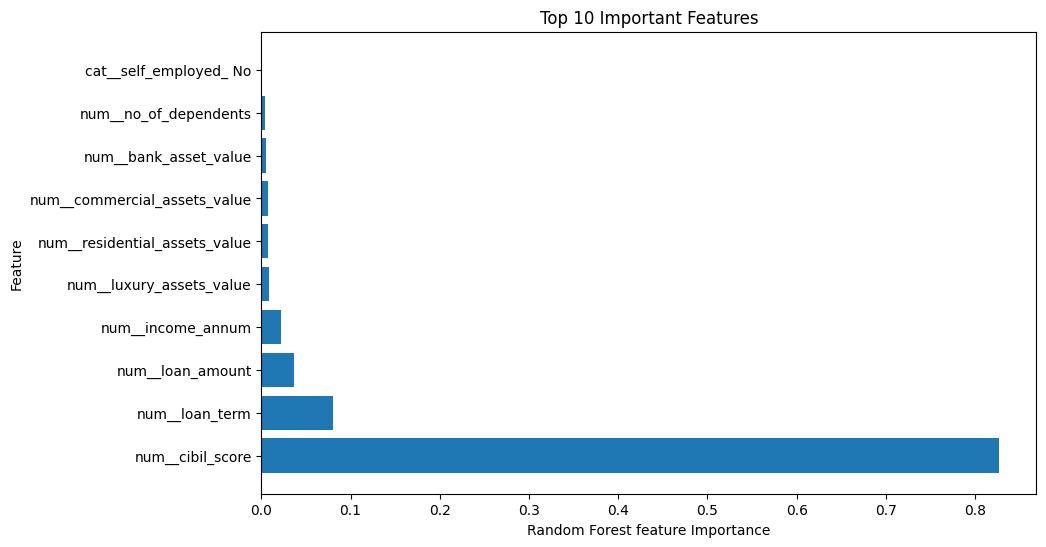

In [84]:

preprocessor = rf_clf_pipeline.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()
print('feature_names:',feature_names)

importance_df =  pd.DataFrame(
    {
        'Feature' : feature_names,
        'Importance' : feature_importance
    }
)

importance_df = importance_df.sort_values(by='Importance', ascending=False)
print("Top 10 Important Feautures : \n", importance_df.head(10))

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel('Random Forest feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Features')
plt.show()


# Other Possible Model for Stage-1 : XGBoost & LightGBM

In [86]:
import joblib

In [89]:
joblib.dump(rf_clf_pipeline, 'stage_1_rf_classification_pipeline.pkl')

['stage_1_rf_classification_pipeline.pkl']

In [92]:
example_row = X_test.iloc[[0]]
print("Example row for prediction: \n")
display(example_row)

Example row for prediction: 



,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
3933,0,Not Graduate,No,9800000,20100000,16,606,6200000,800000,37300000,8700000


In [93]:
example_row

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
3933,0,Not Graduate,No,9800000,20100000,16,606,6200000,800000,37300000,8700000


In [94]:
example_row.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 3933 to 3933
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          1 non-null      int64 
 1   education                 1 non-null      object
 2   self_employed             1 non-null      object
 3   income_annum              1 non-null      int64 
 4   loan_amount               1 non-null      int64 
 5   loan_term                 1 non-null      int64 
 6   cibil_score               1 non-null      int64 
 7   residential_assets_value  1 non-null      int64 
 8   commercial_assets_value   1 non-null      int64 
 9   luxury_assets_value       1 non-null      int64 
 10  bank_asset_value          1 non-null      int64 
dtypes: int64(9), object(2)
memory usage: 96.0+ bytes
